# MLIP Laboratory

In this lab you will train a **MACE** machine-learned interatomic potential (MLIP) on silicon, evaluate how well it reproduces DFT energies and forces, and then use the model's own learned representations to prune a redundant dataset.

<div style="border-left: 3px solid #DD8452; padding: 8px 14px; background:#fff7f0">
<b>Note:</b> On Google Colab, set <b>Runtime -> Change runtime type</b> to a GPU. CPU works, but training will be very slow.
</div>

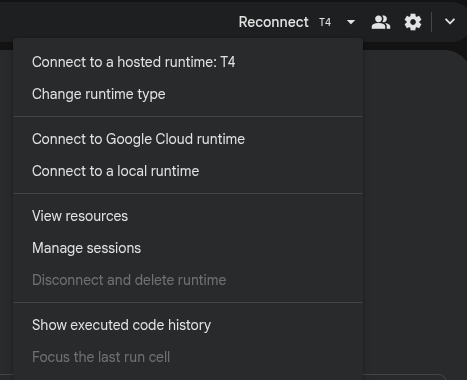


## 0. Setup

In [ ]:
# installing required packages.
!pip install -q mace-torch phonopy ase scikit-learn tqdm #cuequivariance cuequivariance-torch cuequivariance-ops-torch-cu12

In [ ]:
import glob
import os
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from ase import Atoms
from ase.build import bulk
from ase.io import read, write
from sklearn.decomposition import PCA
from sklearn.neighbors import BallTree
from tqdm import tqdm

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

## 1. Dataset: Si GAP-18

The Si GAP-18 dataset contains 2475 DFT(PBE) structures of silicon spanning crystalline phases (diamond, B-tin, BC8, simple cubic, FCC, BCC), amorphous, liquid, surfaces, and defects. It is the standard benchmark for Si interatomic potentials.

Download from the Cambridge University data repository (DOI: [10.17863/CAM.65004](https://doi.org/10.17863/CAM.65004)). Read the paper here: https://journals.aps.org/prx/abstract/10.1103/PhysRevX.8.041048


In [ ]:
!mkdir -p data/raw data/processed

In [ ]:
import pathlib
import urllib.request
import zipfile

ZIP_URL = (
    "https://www.repository.cam.ac.uk/bitstreams/"
    "f17c105a-8466-4729-9fab-94ac03e48106/download"
)
ZIP_FILE = "data/raw/Si_PRX_GAP.zip"

if not os.path.exists(ZIP_FILE):
    print("Downloading (~87 MB) ...")
    urllib.request.urlretrieve(ZIP_URL, ZIP_FILE)
    print("Done.")
else:
    print("Already downloaded.")

with zipfile.ZipFile(ZIP_FILE) as z:
    z.extractall("data/raw/")

print(f"Reading file gp_iter6_sparse9k")
all_data_full = read("data/raw/gp_iter6_sparse9k.xml.xyz", index=":")
all_data = [
    s
    for s in all_data_full
    if (
        "dft_energy" in s.info and "dft_virial" in s.info
    )  # cleaning: drop structures without structures without DFT energy
]

# print(f'Total structures before: {len(all_data_full)}')
print(f"Total number of structures : {len(all_data)}")

### Take a moment to understand how ASE represents the crystal structure.
An `Atoms` object holds the unit cell (3x3 lattice vectors), atomic species, and fractional/Cartesian positions.
- `atoms.get_positions()` (Cartesian, Nx3)
- `atoms.get_scaled_positions()` (fractional),
- `atoms.cell` (lattice vectors),
- `atoms.get_chemical_symbols()` for the element list

Specific to this dataset, the DFT energies and forces are stored as metadata.
Scalar quantities (total energy) in `atoms.info` and per-atom arrays (forces, etc) in `atoms.arrays`. 

In [ ]:
example_atoms = all_data[-1]

print("Chemical symbols:", example_atoms.get_chemical_symbols())
print("Positions (Cartesian):",  example_atoms.get_positions())
print("Scaled positions (fractional):", example_atoms.get_scaled_positions())
print("Cell:",  example_atoms.cell[:])
print()
print("atoms.info:", example_atoms.info.keys())
print()
print("atoms.arrays keys:", list(example_atoms.arrays.keys()))

Take a note of the data `atoms.info['config_type']`, and compare that to **Table 1** in the [paper](https://journals.aps.org/prx/abstract/10.1103/PhysRevX.8.041048). 

In [ ]:
## Exploratory data analysis.
# number of atoms in the dataset
n_atoms = [len(a) for a in all_data]
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(n_atoms, bins=100, linewidth=0.4)
ax.set_xlabel("Number of atoms")
ax.set_ylabel("Count")
ax.set_title("Atom count distribution", fontsize=11)
fig.tight_layout()
plt.show()

In [ ]:
# more data to visualize!!
energies_pa = np.array([a.info["dft_energy"] / len(a) for a in all_data])
max_forces = np.array(
    [np.linalg.norm(a.arrays["dft_force"], axis=1).max() for a in all_data]
)
max_stress = np.array([np.array(a.info["dft_virial"]).max() for a in all_data])
volumes_pa = np.array([a.get_volume() / len(a) for a in all_data])


<div style="border-left: 3px solid #4C72B0; padding: 8px 14px; background:#f5f7ff">
<b>Q:</b> Visualize the distribution of the dataset in terms of the energy and force. Remark on the distribution. 

</div>

In [ ]:
## your answer here:

In [ ]:
# For the ease of training we are removing any structures above 100 atoms in the unit cell
print(f"Size of the dataset before pruning structures above 100 atoms:{len(all_data)}")
all_data = [s for s in all_data if len(s) < 100]
print(f"Size after: {len(all_data)}")

In [ ]:
# Isolated atoms are single-element structures in a large vacuum box used to define the energy zero for each species.
# MACE subtracts their DFT energies (E0s) from all total energies during training, so the model learns interaction energies rather than absolute DFT values.

<div style="border-left: 3px solid #4C72B0; padding: 8px 14px; background:#f5f7ff">
<b>Q:</b> Why do we need isolated atom references during MACE training?
</div>

Answer:

In [ ]:
# Keep a note of this number being used in the training
isolated_atom_Si = [a for a in all_data_full if "isolated_atom" in a.info["config_type"]][0]
isolated_atom_Si.info["dft_energy"] / len(isolated_atom_Si)

In [ ]:
# Split into train/test (90/10).
np.random.seed(42)
idx = np.random.permutation(len(all_data))
n_test = len(all_data) // 10
test_all = [all_data[i] for i in idx[:n_test]]
pool = [all_data[i] for i in idx[n_test:]]

print(f"Total test data  : {len(test_all)}")
print(f"Total train pool : {len(pool)}")

# using ase write to save the training and test data as exyz filetype - feel free to inspect the file.
write("data/processed/train_full.extxyz", pool)
write("data/processed/test_sub.extxyz", test_all)

## 2. Training MACE
MACE provides a convenient function, `mace_run_train`, that handles training. The `!` symbol lets us execute shell commands from within the Jupyter interface.

Keep note of the `E0s='{14:158.54496821}'` value, which we obtained from the isolated atom.


<div style="border-left: 3px solid #4C72B0; padding: 8px 14px; background:#f5f7ff">
<b>Q:</b> Why do we need a radial cutoff (seen in the config below as <code>--r_max=6.0</code>)?
MACE has a higher effective cutoff. Which part of the architecture causes this, and what is the effective value?
<br><br>
<i>Hint: run the cell below and read the MODEL DETAILS section in the MACE log.</i>
</div>

Answer:

In [ ]:
!mace_run_train \
    --name="Si_alldata" \
    --model_dir SAVED_MODELS \
    --train_file=data/processed/train_full.extxyz \
    --valid_fraction=0.05 \
    --loss="weighted" \
    --test_file=data/processed/test_sub.extxyz \
    --E0s='{14:158.54496821}' \
    --energy_key="dft_energy" \
    --forces_key="dft_force" \
    --error_table='PerAtomMAE' \
    --model="MACE" \
    --compute_force=true \
    --hidden_irreps='128x0e + 128x1o' \
    --r_max=6.0 \
    --max_num_epochs=90 \
    --swa \
    --start_swa=40 \
    --ema \
    --ema_decay=0.99 \
    --amsgrad \
    --restart_latest \
    --device=cuda \
    2>&1 | tee logfolder/Si_alldata.txt

In [ ]:
# Scroll through the output. Towards the end, once training is complete, you will find useful statistics.

## 3. Evaluate the model


In [ ]:
## We store the trained model in a dictionary (this will be useful later).

from mace.calculators import MACECalculator

def evaluate(calc, structs):
    e_true, e_pred, f_max_true, f_max_pred, f_mae_pa = [], [], [], [], []

    for s in tqdm(structs, leave=False):
        atoms = s.copy()
        atoms.calc = calc
        n = len(atoms)

        e_true.append(s.info["dft_energy"] / n)
        e_pred.append(atoms.get_potential_energy() / n)

        f_dft = s.arrays["dft_force"]
        f_mace = atoms.get_forces()

        f_max_true.append(np.linalg.norm(f_dft, axis=1).max())
        f_max_pred.append(np.linalg.norm(f_mace, axis=1).max())

        # per-atom force error: norm of (F_pred - F_true) for each atom, then mean
        f_mae_pa.append(np.linalg.norm(f_mace - f_dft, axis=1).mean())

    return map(np.array, [e_true, e_pred, f_max_true, f_max_pred, f_mae_pa])


test_structs = read("data/processed/test_sub.extxyz", index=":")
calcs = {}
for name in ["Si_alldata",]:
    p = f"SAVED_MODELS/{name}_stagetwo.model"
    if os.path.exists(p):
        calcs[name] = MACECalculator(
            model_paths=p, device=device, default_dtype="float32"
        )
print(f"Using these models :{list(calcs.keys())}")
results = {name: evaluate(calc, test_structs) for name, calc in calcs.items()}

df = pd.concat(
    [
        pd.DataFrame(
            {
                f"{name}_e_true": e_true,
                f"{name}_e_pred": e_pred,
                f"{name}_f_max_true": f_max_true,
                f"{name}_f_max_pred": f_max_pred,
                f"{name}_f_mae_pa": f_mae_pa,
            }
        )
        for name, (e_true, e_pred, f_max_true, f_max_pred, f_mae_pa) in results.items()
    ],
    axis=1,
)

In [ ]:
df.head()

In [ ]:
# Parity plot of DFT vs MACE energies, coloured by config_type.
# A perfect model would have all points on the dashed target line.

config_types = [s.info["config_type"] for s in test_structs]

x = df["Si_alldata_e_true"]
y = df["Si_alldata_e_pred"]

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=x, y=y, hue=config_types, s=18, linewidth=0, ax=ax)
ax.plot(x, x, "--", color="0.4", lw=1.2, label="Target")
ax.set_xlabel("DFT energy (eV/atom)")
ax.set_ylabel("MACE energy (eV/atom)")
ax.legend()
fig.tight_layout()
plt.show()

<div style="border-left: 3px solid #4C72B0; padding: 8px 14px; background:#f5f7ff">
<b>Q:</b> Do the same for forces. Plot a parity plot coloured by <code>config_type</code>,
and plot the per-structure force MAE (<code>f_mae_pa</code>) as a histogram.
Which config types have the largest errors? Write a general remark on this model
</div>

## 4. PCA-Based Dataset Pruning

Large DFT datasets often contain near-duplicate structures, i.e. configurations that are so similar that keeping both wastes compute without improving the model.

To find and remove them, we first need a way to measure `structural similarity`.
We do this using the internal representations of a trained MACE model: for each structure, we average the atomic feature vectors from the last message-passing layer into a single embedding vector.
Two structures with similar chemistry and geometry will have similar embeddings; dissimilar structures will be far apart.

With one embedding vector per structure, we then use PCA to compress these high-dimensional vectors into 2D for inspection, and apply a greedy distance filter to remove structures that are too close together in this space.

> **Read more:** [what is PCA?](https://builtin.com/data-science/step-step-explanation-principal-component-analysis) | [Embeddings for materials](https://www.nature.com/articles/s41524-024-01227-4)

In [ ]:
from mace.calculators import mace_mp

calc_mp = mace_mp(
    model="small", device=device, default_dtype="float32"
)  # we use the foundation MACE model here

print("Computing embeddings ...")
embeddings = np.array(
    [calc_mp.get_descriptors(a, invariants_only=True).mean(axis=0) for a in tqdm(pool, desc="embedding")]
)
print(f"Shape: {embeddings.shape}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# scale embeddings
emb_sc = StandardScaler().fit_transform(embeddings)

# PCA
pca_full = PCA(n_components=min(50, emb_sc.shape[1]))
emb_pca_full = pca_full.fit_transform(emb_sc)

cumilative_varience = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.searchsorted(cumilative_varience, 0.95)) + 1

print(f"Components for 95% variance: {n_95}")

<div style="border-left: 3px solid #4C72B0; padding: 8px 14px; background:#f5f7ff">
<b>Q:</b> In your own words, describe what we are doing here. What is the significance of these 5 components? 
</div>

In [ ]:
# here is an illustration of the first two principle components.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

plt.figure(figsize=(8, 6))
sc = plt.scatter(emb_pca_full[:, 0], emb_pca_full[:, 1], s=10, alpha=0.8)


plt.xlabel(f"PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA plot")
plt.tight_layout()
plt.show()

<div style="border-left: 3px solid #4C72B0; padding: 8px 14px; background:#f5f7ff">
<b>Q:</b> We compressed the 256-dimensional MACE descriptor for each structure down to two dimensions via PCA (PC1: 60.7%, PC2: 25.4% variance explained). The plot shows distinct clusters rather than a uniform cloud. What structural or dataset property do you think drives this grouping? Feel free to illustrate it within the plot.
</div>

In [ ]:
## Answer

Since the structures live in a high-dimensional space and nearby structures (which carry redundant information for the model) are grouped together, we can define a `sphere of influence` and keep only one structure per `locality`, defined by a threshold.


In [ ]:
def greedy_dedup(emb, threshold, seed=0):
    order = np.random.default_rng(seed).permutation(len(emb))
    kept = []
    for idx in order:
        if not kept:
            kept.append(idx)
            continue
        d, _ = BallTree(emb[kept]).query(emb[idx : idx + 1], k=1)
        if d[0, 0] > threshold:
            kept.append(idx)
    mask = np.zeros(len(emb), dtype=bool)
    mask[kept] = True
    return mask

In [ ]:
THRESHOLD = 0.2  # Once you have finished this part, feel free to see how this number affects the training.

mask = greedy_dedup(emb_pca_full, THRESHOLD)
print(f"Kept {mask.sum()}/{len(pool)} ({mask.mean()*100:.1f}%)")

In [ ]:
train_pruned = [pool[i] for i in np.where(mask)[0]]
print(f"Full: {len(pool)}, Pruned: {len(train_pruned)}, Test: {len(test_all)}")

In [ ]:
write("data/processed/train_pruned.extxyz", train_pruned)

In [ ]:
!mkdir -p logfolder

#### Training on the subset dataset

In [ ]:
!mace_run_train \
    --name="Si_subset" \
    --model_dir SAVED_MODELS \
    --train_file=data/processed/train_pruned.extxyz \
    --valid_fraction=0.05 \
    --loss="weighted" \
    --test_file=data/processed/test_sub.extxyz \
    --E0s='{14:158.54496821}' \
    --energy_key="dft_energy" \
    --forces_key="dft_force" \
    --error_table='PerAtomMAE' \
    --model="MACE" \
    --compute_force=true \
    --hidden_irreps='128x0e + 128x1o' \
    --r_max=6.0 \
    --max_num_epochs=90 \
    --swa \
    --start_swa=40 \
    --ema \
    --ema_decay=0.99 \
    --amsgrad \
    --restart_latest \
    --device=cuda \
    2>&1 | tee logfolder/Si_subset.txt

In [ ]:
# you can use the same script as before to plot the errors for the reduced model.

# Note that the model name is referenced by the `--name="Si_subset"` field in the model declaration


test_structs = read("data/processed/test_sub.extxyz", index=":")
calcs = {}
for name in ["Si_alldata", "Si_subset"]:
    p = f"SAVED_MODELS/{name}_stagetwo.model"
    if os.path.exists(p):
        calcs[name] = MACECalculator(
            model_paths=p, device=device, default_dtype="float32"
        )
print(f"Using these models :{list(calcs.keys())}")

In [ ]:
results = {name: evaluate(calc, test_structs) for name, calc in calcs.items()}
df = pd.concat(
    [
        pd.DataFrame(
            {
                f"{name}_e_true": e_true,
                f"{name}_e_pred": e_pred,
                f"{name}_f_max_true": f_max_true,
                f"{name}_f_max_pred": f_max_pred,
                f"{name}_f_mae_pa": f_mae_pa,
            }
        )
        for name, (e_true, e_pred, f_max_true, f_max_pred, f_mae_pa) in results.items()
    ],
    axis=1,
)

df.head()

<div style="border-left: 3px solid #4C72B0; padding: 8px 14px; background:#f5f7ff">
<b>Q:</b> Plot the error curves for the full dataset vs the deduplicated training data. What do you see?

</div>


In [ ]:
# Answer:

<div style="border-left: 3px solid #4C72B0; padding: 8px 14px; background:#f5f7ff">
<b>Q:</b> Use a pretrained MACE model as an ASE calculator, and redo the same comparison. What do you see in terms of errors? Could you explain what could be going on?
<br><br>
Hint: use <code>calc_mp = mace_mp(model='medium', device=device, default_dtype='float32')</code> to obtain the model, and append this to the <code>calcs</code> dictionary with an appropriate name e.g. <code>calcs['mace_pretrained_medium'] = calc_mp</code>. Then run the same script above with appropriate modifications.
</div>


In [ ]:
# Answer: